In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
kohli=np.loadtxt(r"C:\Users\heet5\Downloads\batting\kohli.txt")
sachin=np.loadtxt(r"C:\Users\heet5\Downloads\batting\sachin.txt")
sehwag=np.loadtxt(r"C:\Users\heet5\Downloads\batting\sehwag.txt")

In [3]:
kohli.shape

(291,)

# Approach 1: Sequential Sampling
### The dataset is divided sequentially into groups of three observations (e.g., 1–3, 4–6, etc.), where each group represents a 3-match series.
### For each series, the total score is computed and the maximum score across all such sequential series is used to estimate the 80% confidence interval.

In [4]:
# max_score give array that contain maximum scores in 'n' match_series (here n = 3)
def max_score(player_runs, match_series):
   a = range(0,len(player_runs),match_series)
   maximum_score=[]
   for i in a:
       maximum_score.append(np.max([player_runs[i], player_runs[i+1], player_runs[i+2]]))
   return maximum_score

In [5]:
# give bootstrap data ,m is repetation 
def bootstrap_data(max_score,m):  
   bootstrap_data=[]
   for x in range(m):
       bootstrap_data.append( np.random.choice(max_score) )
   return bootstrap_data

In [6]:
def confidance_int(data,n): # give n% confidance interval
     return np.percentile(data,[50 - (n/2.0) , 50 + (n/2.0)])
    

In [7]:
max_kohli=max_score(kohli,3)
max_kohli;

In [8]:
bootstrap_kohli = bootstrap_data(max_kohli,97)
bootstrap_kohli;

Text(0.5, 1.0, 'kohli')

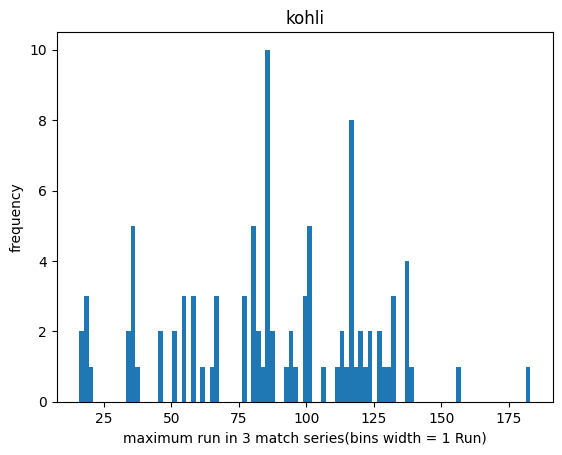

In [9]:
plt.hist(bootstrap_kohli,bins=97)
plt.xlabel('maximum run in 3 match series(bins width = 1 Run)')
plt.ylabel('frequency')
plt.title('kohli')

In [10]:
confidance_int(bootstrap_kohli,80)

array([ 35. , 131.8])

In [11]:
# so 80% confidance interval is as above

In [12]:
# 3 batsman : Kohli, Sachin, Sehwag
 # add one ODI score in sehwag data as before it has 245 which is not divisible by 3
kohli_new=kohli[:246] # as sehwag played 246 matches
sachin_new=sachin[:246]
sehwag.shape  

(246,)

In [13]:
all_three = kohli_new + sachin_new + sehwag # sum elementwise

In [14]:
len(all_three)

246

In [15]:
all_max = max_score(all_three,3)
all_bootstrap =  bootstrap_data(all_max, 246//3)
all_80_interval = confidance_int(all_bootstrap,80)

In [16]:
all_80_interval

array([ 91. , 308.6])

Text(0.5, 1.0, 'kohli + sachin + sehwag')

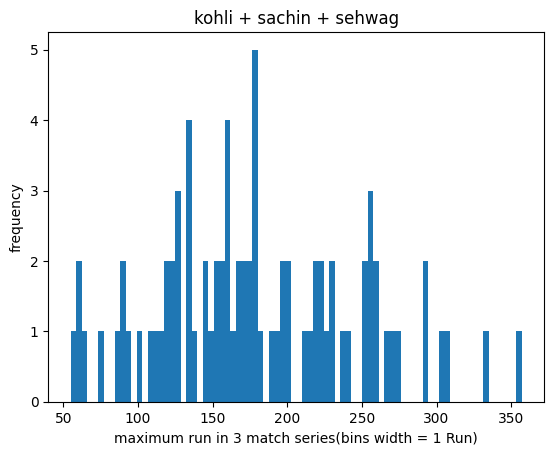

In [17]:
plt.hist(all_max,bins= 246//3)
plt.xlabel('maximum run in 3 match series(bins width = 1 Run)')
plt.ylabel('frequency')
plt.title('kohli + sachin + sehwag')

# Approach 2: Random Sampling
### Three observations are randomly selected from the dataset to simulate a 3-match series, and this process is repeated multiple times.
### The maximum score from each randomly generated series is recorded, and these values are used to compute the 80% confidence interval.

Text(0, 0.5, 'frequency')

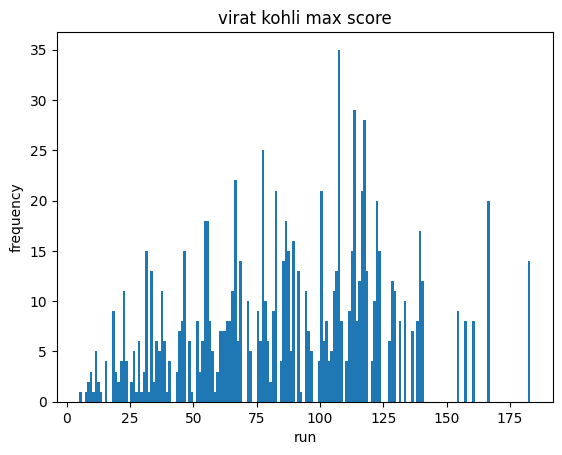

In [18]:
m=1000
vk_max=[]
for i in range(m):
    vk1=random.choice(kohli)
    vk2=random.choice(kohli)
    vk3=random.choice(kohli)
    vk_max.append(np.max([vk1,vk2,vk3]))
    vk_bin = int(np.max(vk_max) -np.min(vk_max))
_ = plt.hist(vk_max,bins=vk_bin)
plt.title('virat kohli max score')
plt.xlabel('run')
plt.ylabel('frequency')

In [19]:
confidance_int(vk_max,80)

array([ 33.9, 136. ])

Text(0, 0.5, 'frequency')

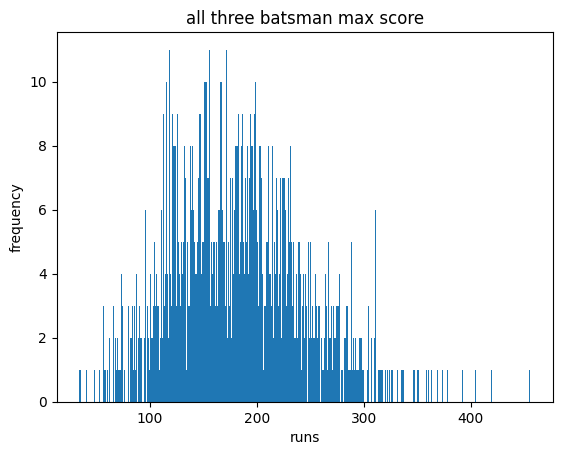

In [20]:
max_run = []
for i in range(m):
    
   k1 = random.choice(kohli)
   sa1 = random.choice(sachin)
   se1= random.choice(sehwag)
    
   k2 = random.choice(kohli_new)
   sa2 = random.choice(sachin)
   se2= random.choice(sehwag)

   k3= random.choice(kohli_new)
   sa3 = random.choice(sachin)
   se3= random.choice(sehwag)

   max_run.append(np.max([k1+sa1+se1, k2+sa2+se2, k3+sa3+se3]))
   all_bin = int(np.max(max_run) - np.min(max_run))
_=plt.hist(max_run,bins=all_bin)
plt.title('all three batsman max score')
plt.xlabel('runs')
plt.ylabel('frequency')

In [21]:
confidance_int(max_run,80)

array([108.9, 267.1])